In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================
# LOAD DATA
# ============================================

train = pd.read_csv("../data/train.csv")

test = pd.read_csv("../data/test.csv")

meal_info = pd.read_csv(
    "../data/meal_info.csv"
)

center_info = pd.read_csv(
    "../data/fulfilment_center_info.csv"
)

print(train.shape)
print(test.shape)

(456548, 9)
(32573, 8)


In [3]:
# ============================================
# MERGE DATASETS
# ============================================

df = train.merge(
    meal_info,
    on="meal_id",
    how="left"
)

df = df.merge(
    center_info,
    on="center_id",
    how="left"
)

print(df.shape)

df.head()

(456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [4]:
# ============================================
# DATA OVERVIEW
# ============================================

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   category               456548 non-null  str    
 10  cuisine                456548 non-null  str    
 11  city_code              456548 non-null  int64  
 12  region_code            456548 non-null  int64  
 13  center_type            456548 non-null  str    
 14  op_area                456548 non-null  float64

np.int64(0)

In [5]:
# ============================================
# FEATURE ENGINEERING
# ============================================

df["discount"] = (
    df["base_price"]
    -
    df["checkout_price"]
)

df["discount_pct"] = (
    df["discount"]
    /
    df["base_price"]
) * 100

In [6]:
# ============================================
# ENCODE CATEGORICAL FEATURES
# ============================================

df_model = pd.get_dummies(
    df,
    columns=[
        "category",
        "cuisine",
        "center_type"
    ],
    drop_first=True
)

In [7]:
# ============================================
# FEATURES AND TARGET
# ============================================

X = df_model.drop(
    columns=[
        "num_orders",
        "id"
    ]
)

y = df_model["num_orders"]

In [8]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# ============================================
# LINEAR REGRESSION
# ============================================

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(
    X_test
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_lr
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_lr
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred_lr
    )
)

MAE: 162.08296995144008
RMSE: 296.48950770802594
R2: 0.42369352298001683


In [10]:
# ============================================
# RANDOM FOREST
# ============================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_rf
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_rf
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred_rf
    )
)

MAE: 68.81793746577593
RMSE: 145.41245953350784
R2: 0.8613761095386362


In [11]:
# ============================================
# GRADIENT BOOSTING
# ============================================

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(
    X_train,
    y_train
)

pred_gbr = gbr.predict(
    X_test
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_gbr
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_gbr
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred_gbr
    )
)

MAE: 117.16529015768211
RMSE: 223.80198563213307
R2: 0.6716305743102665


In [12]:
# ============================================
# XGBOOST
# ============================================

xgb = XGBRegressor(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42

)

xgb.fit(
    X_train,
    y_train
)

pred_xgb = xgb.predict(
    X_test
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred_xgb
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_xgb
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred_xgb
    )
)

MAE: 72.72608947753906
RMSE: 140.21779933375078
R2: 0.8711035251617432


In [13]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "R2":[
        0.417,
        0.855,
        0.667,
        0.871
    ]

})

comparison

,Model,R2
0,Linear Regression,0.417
1,Random Forest,0.855
2,Gradient Boosting,0.667
3,XGBoost,0.871


In [14]:
import joblib

joblib.dump(
    xgb,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

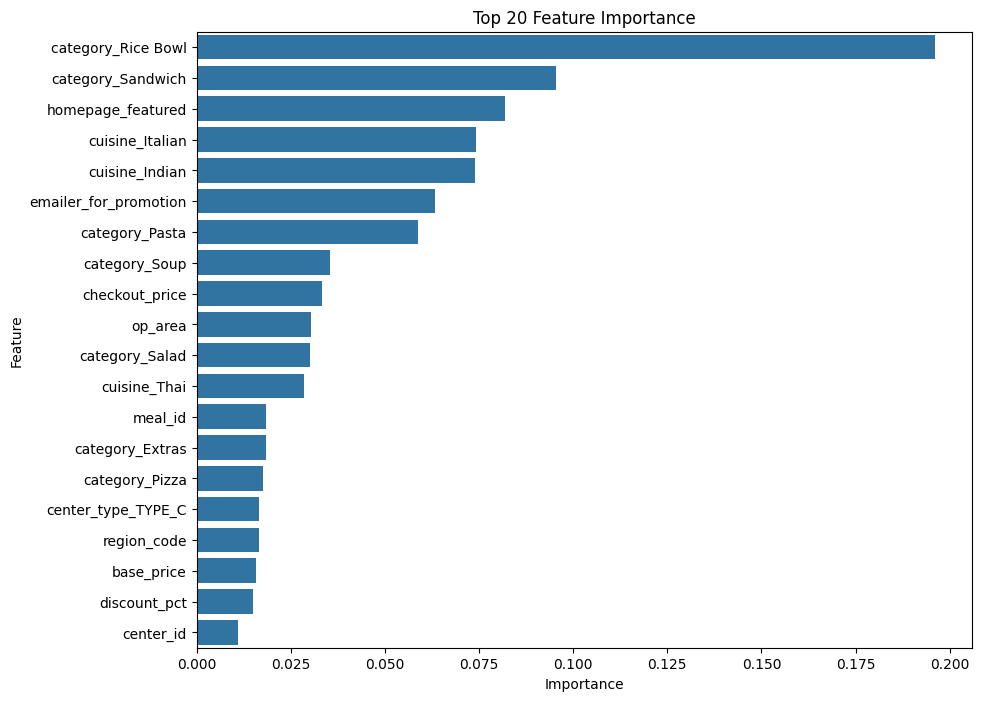

In [15]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": xgb.feature_importances_

})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

top20 = importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance")

plt.savefig(
    "../images/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

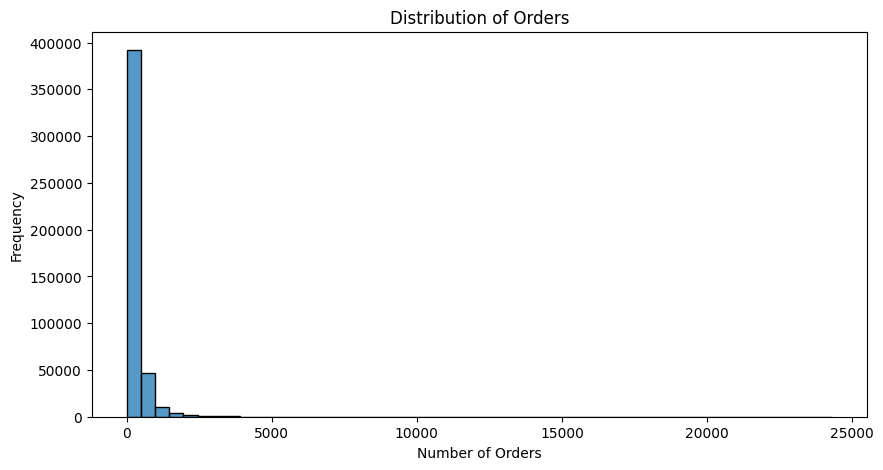

In [16]:
# ============================================
# DEMAND DISTRIBUTION
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["num_orders"],
    bins=50
)

plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")

plt.savefig(
    "../images/demand_distribution.png",
    bbox_inches="tight"
)

plt.show()

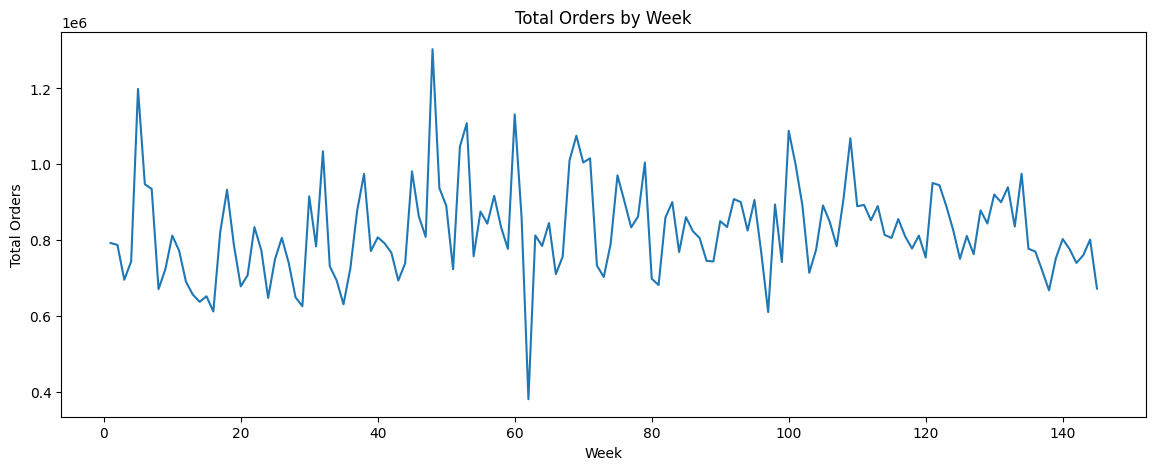

In [17]:
# ============================================
# WEEKLY DEMAND TREND
# ============================================

weekly_orders = (
    df.groupby("week")["num_orders"]
      .sum()
)

plt.figure(figsize=(14,5))

plt.plot(
    weekly_orders.index,
    weekly_orders.values
)

plt.title("Total Orders by Week")
plt.xlabel("Week")
plt.ylabel("Total Orders")

plt.savefig(
    "../images/weekly_demand.png",
    bbox_inches="tight"
)

plt.show()

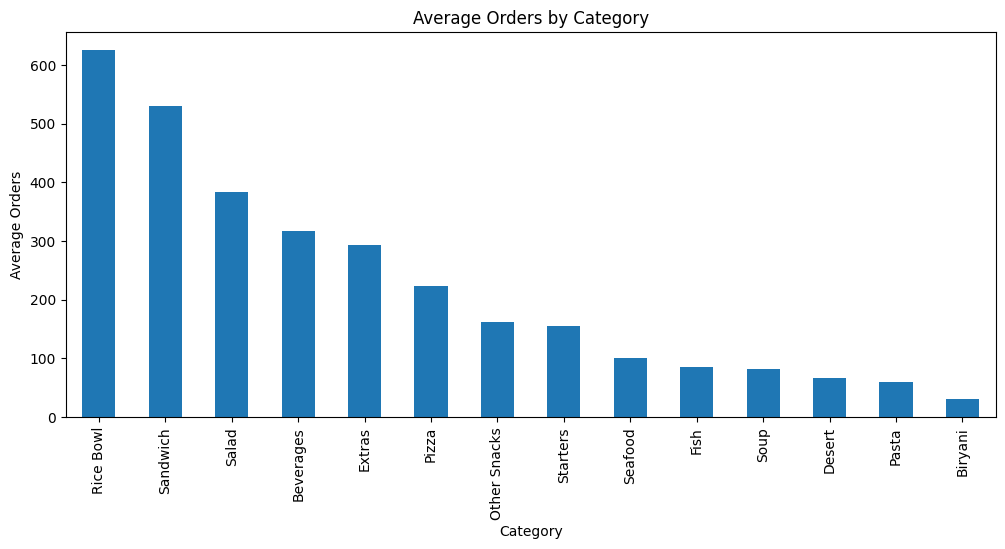

In [18]:
# ============================================
# CATEGORY ANALYSIS
# ============================================

category_orders = (
    df.groupby("category")["num_orders"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

category_orders.plot(
    kind="bar"
)

plt.title("Average Orders by Category")
plt.xlabel("Category")
plt.ylabel("Average Orders")

plt.savefig(
    "../images/category_analysis.png",
    bbox_inches="tight"
)

plt.show()

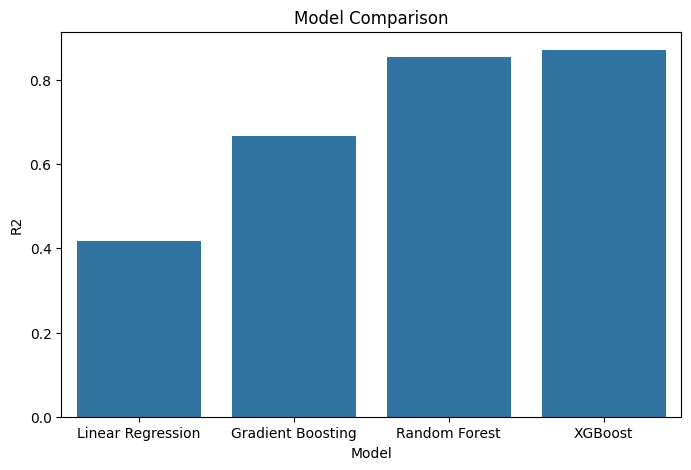

In [19]:
# ============================================
# MODEL COMPARISON
# ============================================

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Gradient Boosting",
        "Random Forest",
        "XGBoost"
    ],

    "R2":[
        0.417,
        0.667,
        0.855,
        0.871
    ]

})

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2"
)

plt.title("Model Comparison")

plt.savefig(
    "../images/model_comparison.png",
    bbox_inches="tight"
)

plt.show()